In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Correlation across all genes

In [2]:
# Configuration and paths
mac = 20
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

abs_phenotypes = True

# Load annotation configuration
if abs_phenotypes:
    config_path = "/home/dnanexus/ukbgym/config_wgs.yaml" # If abs_pheno then deleteriousness direction
else:    
    config_path = "/home/dnanexus/ukbgym/config_olink.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1


In [3]:
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205.parquet")
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
min_range = -100
max_range = +0

anno_wide = (
    anno
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # filter_expression &

        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
    # .filter(pl.col('gene_name').is_in(['LDLR', 'APOB']))
)

anno_wide

mobi_lip_full,cadd_raw,consequence_missense_variant,absplice_dna_max,low_complexity_domain,encode_pels,id,encode_dels,five_prime_utr_variant_consequence_uaug_gained,promoterai_abs,encode_tf,gpn_star_llr_calibrated_mean,am_pathogenicity,consequence_splice_acceptor_variant,consequence_stop_gained,esmscoremissense,consequence_synonymous_variant,mobi_curated_disorder_priority,verphylop,score_pai3d,gpn_score,abexp_abs_max,consequence_stop_lost,promoterai,dist_to_tss,encode_pls,encode_ca_tf,consequence_start_lost,pangolin_score,loftee_hc,gene_length,ted_domain,consequence_frameshift_variant,consequence_splice_donor_variant,delta_score,five_prime_utr_variant_consequence_ustop_lost,absplice2_max,gene_name,five_prime_utr_variant_consequence_ustop_gained,tss,strand,five_prime_utr_variant_consequence_uaug_lost,region
bool,f32,i32,f32,bool,bool,str,bool,u8,f32,bool,f32,f32,i32,i32,f32,i32,bool,f32,f32,f32,f32,i32,f32,i64,bool,bool,i32,f32,i8,i64,bool,i32,i32,f32,u8,f32,str,u8,i64,str,u8,str
false,0.424028,0,0.003,false,false,"""chr1:212413961:C:T""",false,0,0.0,false,-0.228884,0.0,0,0,0.0,0,false,0.079,0.0,-1.38,2.910019,0,0.0,940,false,false,0,0.0,0,50975,false,0,0,0.0,0,0.000321,"""PACC1""",0,212414901,"""-1""",0,"""ENSG00000065600"""
false,-0.383115,0,0.001,false,false,"""chr21:26024903:C:A""",false,0,0.0,false,-0.091653,0.0,0,0,0.0,0,false,-0.906,0.0,-1.44,0.019552,0,0.0,146225,false,false,0,0.04,0,290580,false,0,0,0.0,0,0.000034,"""APP""",0,26171128,"""-1""",0,"""ENSG00000142192"""
false,0.069795,0,0.001,false,false,"""chr2:9307877:C:T""",true,0,0.0,false,-0.539465,0.0,0,0,0.0,0,false,-0.084,0.0,-1.47,0.005501,0,0.0,101113,false,false,0,0.0,0,198920,false,0,0,0.0,0,0.000033,"""ASAP2""",0,9206764,"""1""",0,"""ENSG00000151693"""
false,0.356601,0,0.001,false,false,"""chr1:202731695:A:T""",false,0,0.0,false,-0.249852,0.0,0,0,0.0,0,false,0.665,0.0,-1.66,0.006438,0,0.0,76792,false,false,0,0.0,0,83994,false,0,0,0.0,0,0.000033,"""KDM5B""",0,202808487,"""-1""",0,"""ENSG00000117139"""
false,-0.322957,0,0.001,false,false,"""chr1:212407640:G:C""",false,0,0.0,false,0.929578,0.0,0,0,0.0,0,false,-1.454,0.0,-0.58,0.005501,0,0.0,7261,false,false,0,0.0,0,50975,false,0,0,0.0,0,0.000033,"""PACC1""",0,212414901,"""-1""",0,"""ENSG00000065600"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
false,-0.197536,0,0.0,false,false,"""chr1:247344628:T:C""",false,0,0.0,false,1.181323,0.0,0,0,0.0,0,false,0.129,0.0,-0.33,0.0,0,0.0,-71527,false,false,0,0.0,0,32954,false,0,0,0.0,0,0.0,"""NLRP3""",0,247416155,"""1""",0,"""ENSG00000162711"""
false,0.16376,0,0.0,false,false,"""chr9:127807502:A:T""",true,0,0.0,false,0.43518,0.0,0,0,0.0,0,false,0.129,0.0,-1.25,0.0,0,0.0,47156,false,false,0,0.0,0,39647,false,0,0,0.0,0,0.0,"""ENG""",0,127854658,"""-1""",0,"""ENSG00000106991"""
false,0.447299,0,0.0,false,false,"""chr1:247353822:T:C""",false,0,0.0,false,1.050574,0.0,0,0,0.0,0,false,0.129,0.0,-0.12,0.0,0,0.0,-62333,false,false,0,0.0,0,32954,false,0,0,0.0,0,0.0,"""NLRP3""",0,247416155,"""1""",0,"""ENSG00000162711"""


In [4]:
selected_annos = anno_config_df.filter(
    (pl.col('category').is_in(['plof', 'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'])) # CDS
    # pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation']) # missense
    # pl.col('category').is_in(['genetic_diversity', 'conservation', 'splicing']) # 'splicing'

    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir'])) # non coding
    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])) # introns
)['annotation'].to_list()

melted_anno = (
    anno_wide
    
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    ).with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr1:212413961:C:T""","""ENSG00000065600""","""loftee_hc""",0.0
"""chr21:26024903:C:A""","""ENSG00000142192""","""loftee_hc""",0.0
"""chr2:9307877:C:T""","""ENSG00000151693""","""loftee_hc""",0.0
"""chr1:202731695:A:T""","""ENSG00000117139""","""loftee_hc""",0.0
"""chr1:212407640:G:C""","""ENSG00000065600""","""loftee_hc""",0.0
…,…,…,…
"""chr1:247344628:T:C""","""ENSG00000162711""","""abexp_abs_max""",0.0
"""chr9:127807502:A:T""","""ENSG00000106991""","""abexp_abs_max""",0.0
"""chr1:247353822:T:C""","""ENSG00000162711""","""abexp_abs_max""",0.0


In [5]:
# --- 1. Lazily prepare the filter keys ---

# Read Olink RVAT significant
olnk_subset = pl.read_csv('/home/dnanexus/data_dir/olink/olink_genebass1e6_371genes.tsv', separator='\t')
olnk_rvat_genes = (
    pl.read_csv('/home/dnanexus/data_dir/olink/olink_rvat_fdr.tsv', separator='\t')
    .filter(pl.col('is_plof_significant_fdr')==True)
    .filter(pl.col('n_pos')>=10)
    .filter(pl.col('gene').is_in(olnk_subset['region']))['gene'].to_list()
)
olnk_rvat_genes = [g+'_olink' for g in olnk_rvat_genes]


# Read Olink phenotype data
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

# Merge phenotype data and annotation data
gp_corr_df = (
    olink_appv
    .filter(
        (pl.col('phenotype').is_in(olnk_rvat_genes)) &
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(pl.col('mean_pheno_value'))
    )
    .join(
        melted_anno.lazy(), 
        on="id", 
        how="inner"
    )
    .filter(
        pl.col('region') + '_olink' == pl.col('phenotype')
    )
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['mean_pheno_value', 'annotation_score']
    )
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
    )
    .rename({
        'phenotype': 'olink_prot',
    })
    .collect(engine='streaming')
)

gp_corr_df

/tmp/ipykernel_283197/240589107.py:9: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,olink_prot,annotation,n_variants,correlation
str,str,str,u64,f64
"""ENSG00000164530""","""ENSG00000164530_olink""","""cadd_raw""",1644,0.065539
"""ENSG00000139540""","""ENSG00000139540_olink""","""absplice2_max""",1281,0.013918
"""ENSG00000105472""","""ENSG00000105472_olink""","""verphylop""",852,0.07555
"""ENSG00000187800""","""ENSG00000187800_olink""","""score_pai3d""",2535,NaN
"""ENSG00000139540""","""ENSG00000139540_olink""","""cadd_raw""",1281,0.083892
…,…,…,…,…
"""ENSG00000171105""","""ENSG00000171105_olink""","""gpn_star_llr_calibrated_mean""",11861,-0.006324
"""ENSG00000204381""","""ENSG00000204381_olink""","""cadd_raw""",2021,0.07986
"""ENSG00000175445""","""ENSG00000175445_olink""","""cadd_raw""",7334,0.014799


In [6]:
gp_corr_df = (
    gp_corr_df
    .select(['region', 'olink_prot', 'annotation', 'n_variants', 'correlation'])
    .join(
        anno_config_df,
        on='annotation'
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('annotation_dir')
    )
)

gp_corr_df #['annotation'].value_counts(sort=True)

region,olink_prot,annotation,n_variants,correlation,category,color,label,annotation_dir,corr_beta
str,str,str,u64,f64,str,str,str,i8,f64
"""ENSG00000164530""","""ENSG00000164530_olink""","""cadd_raw""",1644,0.065539,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.065539
"""ENSG00000139540""","""ENSG00000139540_olink""","""absplice2_max""",1281,0.013918,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.013918
"""ENSG00000105472""","""ENSG00000105472_olink""","""verphylop""",852,0.07555,"""conservation""","""#942c80""","""Vertebrate PhyloP""",1,0.07555
"""ENSG00000187800""","""ENSG00000187800_olink""","""score_pai3d""",2535,NaN,"""missense""","""#feb72d""","""PrimateAI-3D""",1,NaN
"""ENSG00000139540""","""ENSG00000139540_olink""","""cadd_raw""",1281,0.083892,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.083892
…,…,…,…,…,…,…,…,…,…
"""ENSG00000171105""","""ENSG00000171105_olink""","""gpn_star_llr_calibrated_mean""",11861,-0.006324,"""conservation""","""#942c80""","""GPN-Star""",-1,0.006324
"""ENSG00000204381""","""ENSG00000204381_olink""","""cadd_raw""",2021,0.07986,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.07986
"""ENSG00000175445""","""ENSG00000175445_olink""","""cadd_raw""",7334,0.014799,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.014799


In [7]:
consistent_genes = (
    gp_corr_df
    .drop_nulls().drop_nans()
    .group_by(['region'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == gp_corr_df['annotation'].n_unique())
)

filt_corr_df = gp_corr_df.join(consistent_genes, on=['region'], how='inner')
# filt_corr_df = gp_corr_df.filter(pl.col("n_variants") > 10)  # Filter for groups with more than 10 variants
filt_corr_df = gp_corr_df.filter(pl.col("n_variants") > 100)
filt_corr_df.sort('corr_beta', descending=True)

region,olink_prot,annotation,n_variants,correlation,category,color,label,annotation_dir,corr_beta
str,str,str,u64,f64,str,str,str,i8,f64
"""ENSG00000187800""","""ENSG00000187800_olink""","""score_pai3d""",2535,NaN,"""missense""","""#feb72d""","""PrimateAI-3D""",1,NaN
"""ENSG00000145012""","""ENSG00000145012_olink""","""absplice2_max""",46731,NaN,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,NaN
"""ENSG00000106853""","""ENSG00000106853_olink""","""score_pai3d""",3658,NaN,"""missense""","""#feb72d""","""PrimateAI-3D""",1,NaN
"""ENSG00000145012""","""ENSG00000145012_olink""","""absplice_dna_max""",46731,NaN,"""splicing""","""#28a745""","""AbSplice (max)""",1,NaN
"""ENSG00000154240""","""ENSG00000154240_olink""","""pangolin_score""",32647,NaN,"""splicing""","""#28a745""","""Pangolin""",1,NaN
…,…,…,…,…,…,…,…,…,…
"""ENSG00000129214""","""ENSG00000129214_olink""","""gpn_star_llr_calibrated_mean""",2063,0.039451,"""conservation""","""#942c80""","""GPN-Star""",-1,-0.039451
"""ENSG00000243989""","""ENSG00000243989_olink""","""loftee_hc""",1312,-0.03956,"""plof""","""#E31A1C""","""LOFTEE HC""",1,-0.03956
"""ENSG00000126458""","""ENSG00000126458_olink""","""loftee_hc""",1131,-0.046742,"""plof""","""#E31A1C""","""LOFTEE HC""",1,-0.046742


In [8]:
# Filter to only those with sign agreement
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 5
Inconsistent (region, phenotype) pairs: 0


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 44 rows containing non-finite values.


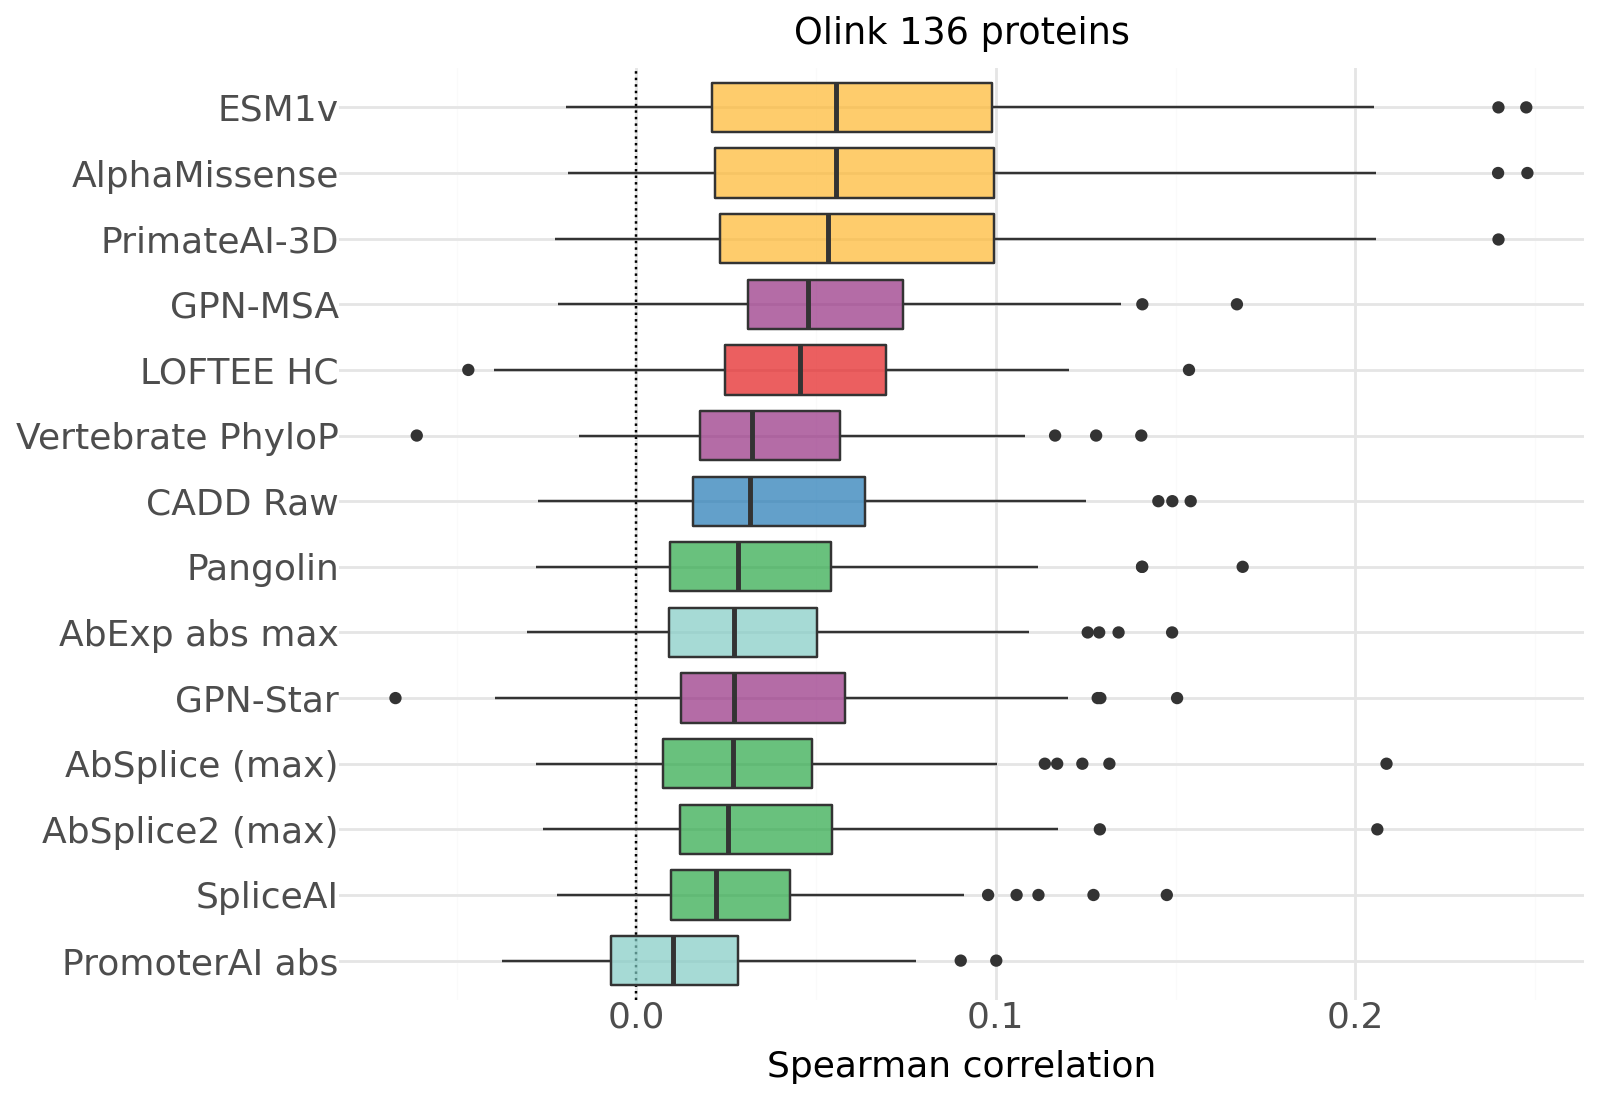

In [11]:
med_df = filt_corr_df.drop_nans().group_by("annotation").agg([
    pl.col("corr_beta").median().alias("median_abs_corr"),
])

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=True)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y="corr_beta", fill="annotation"))
    + geom_hline(aes(yintercept=0), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    # lims(
    #     y=(-0.1, 0.3)
    # ) +
    + labs(
        x="",
        y="Spearman correlation",
        title=f"Olink {len(corr_pd['region'].unique())} proteins"
            # \nmissense variants"
            # \nGene body ±5kb"
            # \nTSS [{min_range}bp, {max_range}bp]"
            # \nsplice donor/acceptor variants"
    )
    + coord_flip()
    + theme(
        figure_size=(8, 5.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [10]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "corr_beta"])

    merged = df_a.join(df_b, on=["region"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_283197/863415217.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""gpn_star_llr_calibrated_mean""","""gpn_score""",136,369.0,1.2029e-20
"""promoterai_abs""","""esmscoremissense""",136,467.0,8.7402e-20
"""promoterai_abs""","""gpn_score""",136,477.0,1.0674e-19
"""promoterai_abs""","""cadd_raw""",136,1134.0,1.9370e-14
"""esmscoremissense""","""gpn_star_llr_calibrated_mean""",136,1255.0,1.4474e-13
…,…,…,…,…
"""esmscoremissense""","""verphylop""",136,1693.0,1.1908e-10
"""cadd_raw""","""esmscoremissense""",136,1777.0,3.8986e-10
"""cadd_raw""","""gpn_score""",136,2091.0,2.4615e-8
